*NLP @ HSE DSBA, autumn 2026. Author: Daria Andreeva*

# Seminar 1 — Representations of Text

As the course authors we usually struggle with the idea on how to present the key ideas of NLP without showing the "old stuff", that is not used anymore, but at the same time keep the field's evolution presented correctly. This year I'll make an attempt this way: we'll begin with the most boring concepts, that are common for the whole NLP field (text classification and regression), but try to reformulate the underlying ideas onto the actual, a bit more fair and challenging task.

### Why I still have a job (and you're probably going to have it too):

$$\text{classifier} = \text{representation} \times \text{head}$$

(the same claim is also fair to the text-regression tho)

So, today we build a text classifier five different ways and watch what changes. We're gonna have one dataset (AG News), one test set, one table, so the results stay comparable. To do so, every number goes into `results` and stays there. Also, before each run, try to commit out loud to a guess. The gap between your guess and the number is the part worth talking about.

To keep the notebook more useful ang entertaining, there are different types of the tasks:

| Marker | Meaning |
|---|---|
| 🎯 **Live** | We do this together in class |
| 📌 **Bet** | Commit to a guess *before* running the next cell |
| 🏠 **Homework** | Runs, but we skip it in class — go through it yourself, if interested |
| ❓ **Open question** | We will *not* answer this today. That is the point. now, just think about it yourself |

Everything marked 🏠 is fully executable. Nothing is hidden from you. If there are any questions, feel free to ask us!

# Some dependencies

In [ ]:
# Colab setup. If needed, uncomment the following lines to install dependencies and clone the repository
#import sys

#!pip install -q "gensim>=4.4" "scikit-learn>=1.5" "nltk>=3.9" "pandas>=2.2" tiktoken shap lime
#!git clone -q --branch autumn-2026 https://github.com/xufana/dsba_nlp.git
#%cd dsba_nlp/week01_text_representations

In [1]:
import json
import os
import re
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

DATA_DIR = "data"
ART_DIR = "artifacts"

# Flip to True to rebuild every precomputed artifact yourself.
# I will run it without computing the artifacts to save time. Run the notebook with RECOMPUTE = True if you want to test something out by yourself.
RECOMPUTE = False

CLASS_NAMES = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}

# 0. Why learn NLP in 2026?

A fair question. An LLM will classify these headlines without any of the code below. So why does this course exist, and why do I still have a job?

Because the thing we have been solving for seventy years was never "build a model". It was:

> **Turn a string into an object where the operation you care about is cheap.**

That is the whole field. Everything below is one answer to that question, and every answer bought something and paid for something.

| Year | Representation | What became cheap | What it cost |
|---|---|---|---|
| 1957 | distributional hypothesis (Firth) | — | not yet an algorithm |
| 1972 | TF-IDF | ranking by relevance | no semantics, no word order |
| 1990 | LSA | synonymy | dense matrix, no interpretation |
| 2003 | LDA | topic structure | bag of words, brittle to preprocessing |
| 2013 | word2vec | semantic similarity, arithmetic | one word → one vector |
| 2016 | fastText | out-of-vocabulary, morphology | still no context |
| 2018+ | contextual representations | homonymy, word order | cost, non-determinism |

Three claims, and we will check all three against numbers today:

1. **There is no winner.** Every method bought something and paid for something. No new method fully replaced the one existing before it. TF-IDF runs in more production systems in 2026 than any encoder does.
2. **Choosing a representation is an engineering decision**, not a fashion decision. It has a price in latency, memory, labelled data and predictability. And we're here to be able to explain our decision.
3. **The task has not changed since 1957.** Everything this semester is a different answer to the same question.

By block 8 you will have the honest answer to "why do I still have a job", tho. And we can continue discussing it after the seminar as well.

In [2]:
train = pd.read_csv(f"{DATA_DIR}/ag_news_train.csv", sep="\t")
test = pd.read_csv(f"{DATA_DIR}/ag_news_test.csv", sep="\t")

print(f"train: {len(train):,}   test: {len(test):,}")
print(train.label.map(CLASS_NAMES).value_counts().to_string())
train.head(3)

train: 120,000   test: 7,600
label
Business    30000
Sci/Tech    30000
Sports      30000
World       30000


,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2


Classes are balanced, 30 000 each. That is the only reason we can use plain
accuracy today and not think about it again. On an imbalanced dataset this
would be the wrong call — but metric selection is not today's lesson, so we
note it and move on.

Here is our results table. It is the artefact of the seminar; you will fill it
in as we go.

In [3]:
results = []


def record(representation, head, y_true, y_pred, vectorize_s=None, fit_s=None,
           latency_ms=None, note=""):
    # Add one row to the running results table.
    from sklearn.metrics import accuracy_score, f1_score

    results.append({
        "representation": representation,
        "head": head,
        "accuracy": round(accuracy_score(y_true, y_pred), 4),
        "macro_f1": round(f1_score(y_true, y_pred, average="macro"), 4),
        "vectorize_s": None if vectorize_s is None else round(vectorize_s, 1),
        "fit_s": None if fit_s is None else round(fit_s, 1),
        "latency_ms": latency_ms,
        "note": note,
    })
    return pd.DataFrame(results)


def show_results():
    return pd.DataFrame(results)

Before you see any model, label these twelve by hand. Write your answers down.
We will collect the class's agreement rate and it becomes a horizontal line on
every chart today.

Do not look them up. Do not ask a model. The whole value of this number is that
it is yours.

The resulting labelling will be important a bit later. I might be not very original, but still want to remind you something.

In [4]:
# Twelve genuinely contested headlines, hand-picked: the best model's top two
# classes are within a few percentage points on every one of them.
DISPUTED_IDX = [7239, 6007, 6082, 4302, 6325, 4200,
                5955, 7262, 3895, 2295, 1708, 6674]

for n, i in enumerate(DISPUTED_IDX, 1):
    print(f"{n:2d}. {test.text.iloc[i][:150]}")

print("\nCategories: World / Sports / Business / Sci-Tech")
print("Write down your twelve answers. Do not run the next cell yet.")

 1. Week's delay for Delta launcher Boeing's new heavy-lift Delta 4 rocket must wait a further week before making its maiden flight.
 2. Honda aiming for BAR buyout? Motorsport.com. Reports this week suggest that Honda is aiming to either buy BAR or become co-owner of the team by purcha
 3. PeopleSoft Chief Threatens to Sue Over Oracle Statements PeopleSoft's chief executive accused Oracle of spreading misleading information about his sto
 4. Sri Lanka off to positive start Kumar Sangakkara's unbeaten fifty revives Sri Lanka's chances against Pakistan.
 5. JFK killing fades in intensity WASHINGTON: The 41st anniversary of President John F Kennedy #39;s assassination passed on November 22 - a lot more qui
 6. Court: Whales Have No Standing to Sue (AP) AP - A federal appeals court decided Wednesday that marine mammals have no standing to sue to stop the U.S.
 7. BAE included in SFO investigation BAE Systems says it has found out that it is being investigated by the UK's Serious Fraud Off

In [ ]:
# Fill in your own twelve labels, then we pool the class.
# 0 = World, 1 = Sports, 2 = Business, 3 = Sci/Tech
my_labels = []  # e.g. [0, 3, 2, 1, ...]

if my_labels:
    gold = test.label.iloc[DISPUTED_IDX].values
    agreement = (np.array(my_labels) == gold).mean()
    print(f"You agree with the dataset on {agreement:.0%} of the disputed twelve.\n")
    for n, (mine, g, i) in enumerate(zip(my_labels, gold, DISPUTED_IDX), 1):
        mark = " " if mine == g else "X"
        print(f"{mark} {n:2d}. you={CLASS_NAMES[mine]:9s} dataset={CLASS_NAMES[g]:9s} "
              f"| {test.text.iloc[i][:70]}")
    print("\nKeep this number. We come back to it in block 8.")
else:
    print("Fill in my_labels first.")

You agree with the dataset on 42% of the disputed twelve.

   1. you=World     dataset=World     | Week's delay for Delta launcher Boeing's new heavy-lift Delta 4 rocket
   2. you=Sports    dataset=Sports    | Honda aiming for BAR buyout? Motorsport.com. Reports this week suggest
   3. you=Sci/Tech  dataset=Sci/Tech  | PeopleSoft Chief Threatens to Sue Over Oracle Statements PeopleSoft's 
X  4. you=Business  dataset=World     | Sri Lanka off to positive start Kumar Sangakkara's unbeaten fifty revi
   5. you=Sci/Tech  dataset=Sci/Tech  | JFK killing fades in intensity WASHINGTON: The 41st anniversary of Pre
X  6. you=Sports    dataset=Sci/Tech  | Court: Whales Have No Standing to Sue (AP) AP - A federal appeals cour
X  7. you=Sci/Tech  dataset=Business  | BAE included in SFO investigation BAE Systems says it has found out th
X  8. you=Business  dataset=Sci/Tech  | Travel Column: Australia Through Aboriginal Eyes This week's TravelWat
X  9. you=World     dataset=Sci/Tech  | Playing with 

# 1. Tokenization

Tokenization splits a string into units. The set of units becomes your vocabulary, and the vocabulary decides what the model can possibly represent.

We walk up the ladder of preprocessing: rules → regex → library → subword.

In [7]:
from string import punctuation

sample = test.text.iloc[42]
print(sample)

# Level 1: strip punctuation and split on whitespace.
def tokenize_naive(text):
    for p in punctuation:
        text = text.replace(p, " ")
    return text.strip().split()

# Level 2: a regex for "runs of word characters".
def tokenize_regex(text):
    return re.findall(r"\w+", text)

print("\nnaive:", tokenize_naive(sample)[:14])
print("regex:", tokenize_regex(sample)[:14])
print("\nidentical on this headline:", tokenize_naive(sample) == tokenize_regex(sample))

Politics an Afterthought Amid Hurricane (AP) AP - If Hurricane Charley had struck three years ago, President Bush's tour through the wreckage of this coastal city would have been just the sort of post-disaster visit that other presidents have made to the scenes of storms, earthquakes, floods and fires.

naive: ['Politics', 'an', 'Afterthought', 'Amid', 'Hurricane', 'AP', 'AP', 'If', 'Hurricane', 'Charley', 'had', 'struck', 'three', 'years']
regex: ['Politics', 'an', 'Afterthought', 'Amid', 'Hurricane', 'AP', 'AP', 'If', 'Hurricane', 'Charley', 'had', 'struck', 'three', 'years']

identical on this headline: True


In [8]:
import nltk
nltk.download("punkt_tab", quiet=True)
from nltk.tokenize import wordpunct_tokenize, word_tokenize
 
tokenizers = {
    "naive": tokenize_naive,
    "regex": tokenize_regex,
    "wordpunct": wordpunct_tokenize,
    "word_tok": word_tokenize,
}
 
hard_cases = [
    "Contact alex.smith_92@hse.ru for details.",
    "See http://news.com.com/Nokia+joins?tag=nl.e433 for more.",
    "Shares fell 3.5% to $41.20 on Tuesday.",
    "Don't miss #Athens2004 -- it's must-see TV!",
    "Version 2.6.1 ships Q4 2004.",
]
 
for case in hard_cases:
    print(repr(case))
    for name, fn in tokenizers.items():
        toks = fn(case)
        print(f"  {name:10s} {len(toks):2d}  {toks}")
    print()

'Contact alex.smith_92@hse.ru for details.'
  naive       8  ['Contact', 'alex', 'smith', '92', 'hse', 'ru', 'for', 'details']
  regex       7  ['Contact', 'alex', 'smith_92', 'hse', 'ru', 'for', 'details']
  wordpunct  11  ['Contact', 'alex', '.', 'smith_92', '@', 'hse', '.', 'ru', 'for', 'details', '.']
  word_tok    7  ['Contact', 'alex.smith_92', '@', 'hse.ru', 'for', 'details', '.']

'See http://news.com.com/Nokia+joins?tag=nl.e433 for more.'
  naive      12  ['See', 'http', 'news', 'com', 'com', 'Nokia', 'joins', 'tag', 'nl', 'e433', 'for', 'more']
  regex      12  ['See', 'http', 'news', 'com', 'com', 'Nokia', 'joins', 'tag', 'nl', 'e433', 'for', 'more']
  wordpunct  21  ['See', 'http', '://', 'news', '.', 'com', '.', 'com', '/', 'Nokia', '+', 'joins', '?', 'tag', '=', 'nl', '.', 'e433', 'for', 'more', '.']
  word_tok    9  ['See', 'http', ':', '//news.com.com/Nokia+joins', '?', 'tag=nl.e433', 'for', 'more', '.']

'Shares fell 3.5% to $41.20 on Tuesday.'
  naive       9  ['Share

Now look at what each one did.
 
**The email address.** `alex.smith_92@hse.ru` is one thing — an identifier. Only
`word_tokenize` keeps `alex.smith_92` and `hse.ru` intact. `naive` and `regex`
shred it into `alex`, `smith`, `92`, `hse`, `ru`, at which point no downstream
model can ever recover that an email was there.
 
This is also, finally, where our two "identical" tokenizers visibly differ:
`regex` keeps `smith_92` because `_` is a word character, `naive` splits it
because `_` is in `string.punctuation`. Nobody designed that disagreement — it
fell out of two library authors making unrelated decisions.
 
**The URL** shatters into twelve fragments under `naive` and `regex`, twenty-one
under `wordpunct`. `word_tokenize` produces `//news.com.com/Nokia+joins` —
better, but nobody's idea of correct either. There is no right answer here, only
different wrong ones.
 
**The money and the numbers.** `3.5%` becomes `3`, `5`. `$41.20` becomes `41`,
`20`. `2.6.1` becomes `2`, `6`, `1`. On a financial corpus that is not a rounding
error, that is the signal being deleted.
 
**`Don't` is the strange one.** `word_tokenize` returns `Do` + `n't`. It did not
*split* the string — it **rewrote** it. Concatenating the tokens back does not
reproduce the input. Tokenization is not necessarily a partition of the text,
and every tool that assumes it is will break here.

## 1.1 Stemming and lemmatization

The textbook table for English looks like this:

| Surface form | Stem (Porter) | Lemma |
|---|---|---|
| `studies` | `studi` | `study` |
| `going` | `go` | `go` |
| `went` | `went` | `go` |
| `better` (adj.) | `better` | `good` |

📌 **Bet:** run the next cell. Does `nltk`'s lemmatizer reproduce that table?

In [9]:
nltk.download("wordnet", quiet=True)
from nltk.stem import WordNetLemmatizer, PorterStemmer

lem, stem = WordNetLemmatizer(), PorterStemmer()

rows = []
for w in ["studies", "goes", "going", "went", "better", "was", "cats", "people"]:
    rows.append({
        "word": w,
        "stem": stem.stem(w),
        "lemma (default)": lem.lemmatize(w),
        "lemma (pos='v')": lem.lemmatize(w, "v"),
        "lemma (pos='a')": lem.lemmatize(w, "a"),
    })
pd.DataFrame(rows)

,word,stem,lemma (default),lemma (pos='v'),lemma (pos='a')
0,studies,studi,study,study,studies
1,goes,goe,go,go,goes
2,going,go,going,go,going
3,went,went,went,go,went
4,better,better,better,better,good
5,was,wa,wa,be,was
6,cats,cat,cat,cat,cats
7,people,peopl,people,people,people


It does not.

`went → went`. `better → better`. And `was → wa`, which is not a word in any
language. The default is `pos='n'`: the lemmatizer assumes every token is a
noun and strips what looks like a plural `s`.

The textbook table describes lemmatization **with part-of-speech tags**. The
code above is lemmatization **without** them. That is a different operation,
and on this corpus it is roughly an expensive stemmer with worse coverage.

This matters beyond a cute gotcha. Almost every tutorial you will find calls
`.lemmatize(word)` with no POS tag and then prints the textbook table next to
it. Two things are true at once and nobody reconciles them.


## 1.2 Subword tokenization

Everything above draws the word boundary by hand. Modern systems learn it from
data instead. We are not covering *how* BPE trains until later — today just
look at what it produces.

**Bet:** the same sentence in English and in Russian. Which costs more
tokens, and by what factor?

In [ ]:
# !pip install tiktoken

In [10]:
import tiktoken
enc = tiktoken.get_encoding("cl100k_base")

pairs = [
    ("Oil prices soar to an all-time record high.",
     "Цены на нефть взлетели до рекордного уровня."),
    ("The unbelievability of it all.",
     "Невероятность всего происходящего."),
]
for en, ru in pairs:
    te, tr = enc.encode(en), enc.encode(ru)
    print(f"EN {len(te):3d} tokens  {en}")
    print(f"RU {len(tr):3d} tokens  {ru}")
    print(f"   ratio x{len(tr)/len(te):.1f}\n")

print("How a single word gets cut up:")
for w in ["unbelievability", "tokenization", "Sci-Tech", "1,234.56", "нефть"]:
    pieces = [enc.decode([t]) for t in enc.encode(w)]
    print(f"  {w:18s} -> {pieces}")


EN  10 tokens  Oil prices soar to an all-time record high.
RU  21 tokens  Цены на нефть взлетели до рекордного уровня.
   ratio x2.1

EN   8 tokens  The unbelievability of it all.
RU  15 tokens  Невероятность всего происходящего.
   ratio x1.9

How a single word gets cut up:
  unbelievability    -> ['un', 'belie', 'v', 'ability']
  tokenization       -> ['token', 'ization']
  Sci-Tech           -> ['Sci', '-T', 'ech']
  1,234.56           -> ['1', ',', '234', '.', '56']
  нефть              -> ['не', 'ф', 'ть']


Three things fall out of that output:

* The boundary between "words" is not a property of language. It is a decision
  frozen into a trained tokenizer.
* Russian costs two to three times more tokens than English for the same
  content. Somebody pays for that, per API call, forever.
* Numbers, whitespace and casing all get split in ways nobody designed
  deliberately — they fell out of training data statistics.

**Open question:** why exactly does Russian cost more? Is it the alphabet,
the morphology, or the training corpus? How would you test which?

**Later** we'll discuss how BPE actually trains, and what happens when you train your own.

# 2. Preprocessing: both directions

The usual advice is "clean your text": lowercase, drop stopwords, lemmatize.
The usual advice is wrong roughly half the time. The real rule:

> **Preprocessing is chosen by the representation, not by habit.**

We look at both directions.

## 2.1 Where you must not skip it

**Topic modelling.** LDA is a bag of words. It has no notion of synonymy and no
notion of morphology. If you feed it raw text, the top of every topic is `the`,
`and`, `for` — and in a morphologically rich language, one concept scatters
across eight surface forms, so the model ends up modelling grammar instead of
meaning.

In [11]:
# Precomputed: two LDA fits on 20k AG News docs, raw vs lemmatised.
# Slow to fit, so it ships as an artifact. Code: scripts/precompute.py
if RECOMPUTE:
    !python scripts/precompute.py --data-dir data --out artifacts --only lda

with open(f"{ART_DIR}/lda_topics.json") as f:
    lda = json.load(f)

for tag in ["raw", "lemmatised"]:
    print(f"--- {tag}  (vocab {lda[tag]['vocab_size']:,}) ---")
    for i, topic in enumerate(lda[tag]["topics"]):
        print(f"  {i}  {' '.join(topic)}")
    print()

--- raw  (vocab 6,710) ---
  0  and at for game ap with first over season win
  1  and for is new with that on are by internet
  2  gt lt on reuters as and oil its stocks prices
  3  for on million at gold and off american open round
  4  and on for 39 that said by it its us
  5  39 it that its is for and quot has microsoft
  6  on and said iraq reuters for an us at minister
  7  his 39 on he for was and afp as ap

--- lemmatised  (vocab 5,807) ---
  0  quot year world computer cup ibm music still one apple
  1  space game coach india hit back oracle worker left russian
  2  win first new team year game red three league last
  3  reuters stock new percent profit said sale price com quarter
  4  said iraq security reuters official people killed government state say
  5  afp president minister election bush prime palestinian leader champion australia
  6  oil company new microsoft said service software plan corp deal
  7  season 000 day game state point new sunday man night



The raw topics are dominated by function words and HTML debris (`39` is a
mangled `&#39;`, `quot` a mangled `&quot;`). The cleaned topics are actually
readable: markets, conflict, politics, tech.

Here preprocessing is not a tuning knob. It is the difference between a model
that works and a model that models punctuation.

### Where else you cannot skip it:

* **Lexical search and BM25.** Normalization is what makes a query match a
  document at all. `cats` will not find `cat` without it. This does not improve
  a metric — it decides whether retrieval is possible.
* **Dictionary and rule-based methods.** Sentiment lexicons, keyword
  extraction, collocations. The normalized form is the join key.
* **Small data.** On 200 examples, collapsing the vocabulary is real
  regularization, not cosmetics.

## 2.2 Where it destroys the signal

📌 **Bet:** `nltk`'s English stopword list has 198 entries. Is the word `not` one of them?

In [12]:
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords

stop = set(stopwords.words("english"))
print(f"nltk english stopwords: {len(stop)}")

for w in ["not", "no", "nor", "never", "but", "very", "only", "too", "against"]:
    print(f"  {w:9s} in stoplist: {w in stop}")

nltk english stopwords: 198
  not       in stoplist: True
  no        in stoplist: True
  nor       in stoplist: True
  never     in stoplist: False
  but       in stoplist: True
  very      in stoplist: True
  only      in stoplist: True
  too       in stoplist: True
  against   in stoplist: True


In [13]:
def drop_stopwords(text):
    return " ".join(t for t in re.findall(r"\w+", text.lower()) if t not in stop)

for phrase in ["the movie was not good",
               "I would never recommend this",
               "no problems at all, very happy"]:
    print(f"{phrase!r}\n  -> {drop_stopwords(phrase)!r}\n")

'the movie was not good'
  -> 'movie good'

'I would never recommend this'
  -> 'would never recommend'

'no problems at all, very happy'
  -> 'problems happy'



`not good` becomes `good`. `never recommend` becomes `recommend`. That is the
mechanism, and it is real. Whether it costs you accuracy is a separate question
with a measurable answer — 2.3 measures it, and the answer is not the one the
textbook implies.

### Where else it destroys the signal:

* **Authorship attribution and stylometry.** Function words *are* the signal.
  The stoplist deletes exactly what the task is about.
* **NER and casing.** `apple` vs `Apple`.
* **word2vec.** Removing stopwords shifts the context windows and glues
  together words that were six positions apart in the original text. We test
  this in block 6.

## 2.3 Which cleaning, for which task

Ok, we've seen only two experiments. That is enough to remember a story and exactly not
enough to choose a path on a task you have not seen before.

So: twelve experiments side-by-side, six datasets, four task families. Each one flips a single step of preprocessing and holds the split, the seed, the model and the vectorizer fixed, so the difference belongs to the preprocessing and to nothing else. The rows are arranged so the *same* style comes back on a different task.

Take a look at the tasks we've got:

| family | datasets |
|---|---|
| text classification | AG News · movie reviews · sentence polarity · SMS spam · Gutenberg |
| the same task, different amounts of labelled data | AG News at 500 and at 120 000 |
| lexical search | NFCorpus, BM25, nDCG@10 |
| topic modelling | AG News, LDA, NPMI coherence |

📌 **Take a guess, which way would be more effective?** For each of the twelve rows: does the cleaning
**help**, **hurt**, or do **nothing** (a delta under half a point)? Twelve
answers, written down, before you scroll past the next cell.

In [ ]:
import json

GRID = f"{ART_DIR}/preprocessing_grid.json"

# Rebuilding downloads ~6 MB of corpora and takes a few minutes.
# Code for every row: scripts/preprocessing_grid.py
if RECOMPUTE:
    !python scripts/preprocessing_grid.py

grid = json.load(open(GRID))["rows"]

fam = None
for i, r in enumerate(grid, 1):
    if r["family"] != fam:
        fam = r["family"]
        print(f"\n--- {fam} ---")
    print(f"{i:2d}. {r['dataset']:18s} {r['task'][:46]:46s}")
    print(f"    {r['knob']:44s} measured in {r['metric']}")

print("\nTwelve answers: helps / no change / hurts. Write them down first.")

In [ ]:
# 1 = helps, 0 = no change, -1 = hurts. Twelve of them, then run the cell.
my_bets = []  # e.g. [0, 1, -1, 1, -1, -1, 1, 0, 1, 1, 1, -1]

CODE = {1: "helps", 0: "no change", -1: "hurts"}
hits, missed = 0, []

fam = None
for i, r in enumerate(grid):
    if r["family"] != fam:
        fam = r["family"]
        print(f"\n--- {fam} ---")
        print(f"    {'dataset':18s} {'knob':38s} {'base':>8s} {'variant':>8s} "
              f"{'delta':>8s}  verdict")
    mine = CODE.get(my_bets[i]) if i < len(my_bets) else None
    ok = mine == r["verdict"]
    hits += ok
    if mine is not None and not ok:
        missed.append(i)
    print(f"{'' if mine is None else ('  ok' if ok else '  XX'):>4s} "
          f"{r['dataset']:18s} {r['knob'][:38]:38s} "
          f"{r['baseline']:8.4f} {r['variant']:8.4f} {r['delta']:+8.4f}  {r['verdict']}")

if my_bets:
    print(f"\nYou got {hits} / {len(my_bets)}.")
    for i in missed:
        print(f"\n  {i + 1}. {grid[i]['dataset']} · {grid[i]['knob']}")
        print(f"     {grid[i]['note']}")
print("\nEvery row carries its own note: grid[i]['note'].")

Read the columns, not the rows.

**`drop stopwords` appears four times in the first block and answers
differently every time.** Nothing on AG News topics. **+1.0 points** on 700-word
film reviews. **−1.2 points** on 21-word sentences of the *same task*. **−2.2**
on authorship — where that same list, used *alone*, still reaches 0.873 against
a 0.672 majority baseline.

The hidden variable in the two sentiment rows is document length. In a 700-word
review dozens of sentiment words vote, one deleted negation changes almost
nothing, and the denoising wins. In a 21-word sentence `not` can be most of the
evidence there is. Same task, same preprocessing, opposite sign — so "is this good for
sentiment analysis?" was never a well-formed question.

**`Porter stemming` appears three times.** It buys **+1.4 points** on 500
labelled documents, **nothing** on 120 000 of the same documents, and **+1.5
nDCG** in retrieval. Stemming trades precision for coverage: that is a bargain
when you have too little data to learn each surface form, and a bad deal when
you have plenty. In lexical search it is not even a trade — a query and a
document have to share a surface form to match at all, so `treating diabetes`
never meets `treatment of diabetic` without it.

**Two rows contradict the textbook outright.** Shouting and punctuation do not
help spam detection here: `free`, `txt`, `claim` and `win` already separate the
classes, and splitting each word across casings costs more than the casing is
worth. And lemmatising *lowers* topic coherence — because `WordNetLemmatizer`
without POS tags turns `has` into `ha` and `us` into `u` (block 1.1 again), and
those land in the top words of several topics. The gain usually credited to
lemmatisation in 2.1 came from dropping the stoplist, not from the lemmatiser.

**The rule that survives all twelve rows:**

> A preprocessing step is a bet that what it deletes is not what the task needs.
> Whether you win depends on the task, on how much text each document has to
> spare, and on how much labelled data you have — never on the method alone.

🏠 Add a row. `scripts/preprocessing_grid.py` takes one loader, one analyzer and one
metric; a preprocessing step you have an opinion about and a dataset you care about is about
fifteen lines.

# 3. Sparse representations, and fastText

Now we climb the ladder properly, changing **one thing at a time** and putting
every result in the table.


In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.feature_extraction.text import CountVectorizer


## 3.1 What is the vector, actually?

Before running anything on 120 000 documents, build the thing by hand on four.

A **bag of words** represents a document as one number per vocabulary word. The
vocabulary is the columns; each document is a row. That is the whole idea — the
document becomes a point in a space with one axis per word.

In [15]:
toy = [
    "oil prices rise today",
    "oil prices fall today",
    "the team wins the game today",
    "the team loses the game today",
]

cv_toy = CountVectorizer()
counts = cv_toy.fit_transform(toy)
vocab = cv_toy.get_feature_names_out()

print(f"vocabulary ({len(vocab)} words): {list(vocab)}\n")
pd.DataFrame(counts.toarray(), columns=vocab, index=[f"d{i}" for i in range(4)])

vocabulary (10 words): ['fall', 'game', 'loses', 'oil', 'prices', 'rise', 'team', 'the', 'today', 'wins']



,fall,game,loses,oil,prices,rise,team,the,today,wins
d0,0,0,0,1,1,1,0,0,1,0
d1,1,0,0,1,1,0,0,0,1,0
d2,0,1,0,0,0,0,1,2,1,1
d3,0,1,1,0,0,0,1,2,1,0


Four documents, ten columns. `d2` has a `2` under `the` because it says `the`
twice.

Two things are already gone and will not come back: **word order** and
**anything not in the vocabulary**. `d0` and a hypothetical `today rise prices
oil` would be the same row.

### Step 1 — term frequency

Raw counts favour long documents. Divide by the document's length:

$$\text{tf}(t, d) = \frac{N(t, d)}{\sum_k N(k, d)}$$

### Step 2 — inverse document frequency

`today` appears in all four documents, so knowing a document contains `today`
tells you nothing about it. `rise` appears in one, so it is highly informative.
IDF turns that intuition into a number — rare across the corpus means high
weight:

$$\text{idf}(t, D) = \log\frac{|D|}{|\{d : t \in d\}|}$$

📌 **Bet:** what IDF does `sklearn` give to `today`, which is in every document?

In [16]:
tv_toy = TfidfVectorizer()
tfidf_toy = tv_toy.fit_transform(toy)

pd.DataFrame({
    "term": vocab,
    "doc_freq": np.asarray((counts > 0).sum(axis=0)).ravel(),
    "idf (sklearn)": tv_toy.idf_.round(3),
}).sort_values("doc_freq")

,term,doc_freq,idf (sklearn)
0,fall,1,1.916
2,loses,1,1.916
5,rise,1,1.916
9,wins,1,1.916
1,game,2,1.511
3,oil,2,1.511
4,prices,2,1.511
6,team,2,1.511
7,the,2,1.511
8,today,4,1.000


`today` gets **1.0**, not 0. That is the floor, not the formula above.

`sklearn` uses a smoothed variant, `log((1+n)/(1+df)) + 1`, which pretends one
extra document contains every term and then adds 1 so that no weight can reach
zero. A term in every document is downweighted to the minimum, but never
deleted — which will matter in a moment.

### Step 3 — multiply, then normalize

$$\text{tf-idf}(t,d,D) = \text{tf}(t,d)\cdot\text{idf}(t,D)$$

and `sklearn` L2-normalizes each row so that document length stops mattering
entirely.

In [17]:
mat = pd.DataFrame(tfidf_toy.toarray().round(3), columns=vocab,
                   index=[f"d{i}" for i in range(4)])
print(mat.to_string(), "\n")
print("row norms:", np.linalg.norm(tfidf_toy.toarray(), axis=1).round(3))

     fall   game  loses    oil  prices   rise   team    the  today   wins
d0  0.000  0.000  0.000  0.497   0.497  0.631  0.000  0.000  0.329  0.000
d1  0.631  0.000  0.000  0.497   0.497  0.000  0.000  0.000  0.329  0.000
d2  0.000  0.353  0.000  0.000   0.000  0.000  0.353  0.705  0.233  0.447
d3  0.000  0.353  0.447  0.000   0.000  0.000  0.353  0.705  0.233  0.000 

row norms: [1. 1. 1. 1.]


Read the matrix rather than skimming it:

* `today` has the **smallest** non-zero weight in every row (0.329, 0.233). It
  is in every document, so it barely distinguishes anything.
* `rise` in `d0` gets 0.631 — the largest in its row. It appears once, in one
  document, which makes it the most informative thing about `d0`.
* `the` in `d2` gets 0.705, higher than `game` or `team`, purely because it
  occurs twice. Frequency inside a document still counts.
* Every row has length exactly 1. A ten-word and a thousand-word document are
  comparable.

**This is the whole method.** Everything below is the same three steps on a
bigger vocabulary.


## 3.2 Why n-grams

The bag of words threw away word order in step zero, and never got it back.
Here is the bill.

📌 **Bet:** two headlines, same five words, opposite meaning. What is the cosine
similarity of their TF-IDF vectors?

In [19]:
from sklearn.metrics.pairwise import cosine_similarity

pair = ["oil prices fall stocks rise",
        "stocks fall oil prices rise"]

for tag, ng in [("unigrams", (1, 1)), ("unigrams + bigrams", (1, 2))]:
    v = TfidfVectorizer(ngram_range=ng)
    M = v.fit_transform(pair)
    sim = cosine_similarity(M[0], M[1])[0, 0]
    print(f"{tag:20s} dim={M.shape[1]:2d}  cosine = {sim:.3f}")

v = TfidfVectorizer(ngram_range=(1, 2)).fit(pair)
print("\nbigrams that appear:", [t for t in v.get_feature_names_out() if " " in t])

unigrams             dim= 5  cosine = 1.000
unigrams + bigrams   dim=12  cosine = 0.503

bigrams that appear: ['fall oil', 'fall stocks', 'oil prices', 'prices fall', 'prices rise', 'stocks fall', 'stocks rise']


**Exactly 1.000.** To a bag of words these two headlines are *the same
document*. One says oil fell and stocks rose; the other says the opposite. The
representation cannot tell them apart, and no classifier on top of it can
either.

Adding bigrams drops the similarity to 0.503, because `stocks rise` and `stocks
fall` are now different features.

The same failure covers a lot of ground: `not good` and `good not`, `new york
times` and `york new times` — all cosine 1.0 under unigrams.

**What it costs.** An n-gram is just "treat this pair of adjacent words as one
vocabulary entry", so the vocabulary explodes. In our five-word pair, going from
unigrams to bigrams took the dimension from 5 to 12. On AG News you will watch
it go from 29 000 to about 197 000 in a moment.

Word order is not fully recovered — a bigram sees two words, not a sentence —
but you buy back the local part of it, for memory and compute.

That tension is the reason the next three cells exist. Now run it for real,
**changing one thing at a time**, and put every result in the table.

## 3.3 The same three steps on 120 000 documents

In [20]:
def run_sparse(name, vec, head=None):
    t = time.time()
    Xtr, Xte = vec.fit_transform(train.text), vec.transform(test.text)
    vec_s = time.time() - t

    head = head or LogisticRegression(max_iter=1000, random_state=SEED)
    t = time.time()
    head.fit(Xtr, train.label)
    fit_s = time.time() - t

    pred = head.predict(Xte)
    df = record(name, type(head).__name__, test.label, pred, vec_s, fit_s,
                note=f"dim={Xtr.shape[1]:,}")
    print(df.tail(1).to_string(index=False))
    return vec, head, Xtr, Xte

run_sparse("counts, words 1-1", CountVectorizer(min_df=4))
vec_tfidf, clf_tfidf, Xtr_tfidf, Xte_tfidf = run_sparse(
    "tf-idf, words 1-1", TfidfVectorizer(min_df=4, max_df=0.95))

   representation               head  accuracy  macro_f1  vectorize_s  fit_s latency_ms       note
counts, words 1-1 LogisticRegression    0.9093    0.9092          2.1   12.5       None dim=29,350
   representation               head  accuracy  macro_f1  vectorize_s  fit_s latency_ms       note
tf-idf, words 1-1 LogisticRegression    0.9179    0.9177          2.3    3.8       None dim=29,350


## 3.4 Character n-grams

📌 **Bet:** which wins on AG News — word bigrams, or character 3–5-grams?

In [21]:
run_sparse("tf-idf, words 1-2",
           TfidfVectorizer(min_df=4, max_df=0.95, ngram_range=(1, 2)))
show_results()

   representation               head  accuracy  macro_f1  vectorize_s  fit_s latency_ms        note
tf-idf, words 1-2 LogisticRegression    0.9195    0.9193          7.0   15.5       None dim=196,911


,representation,head,accuracy,macro_f1,vectorize_s,fit_s,latency_ms,note
0,"counts, words 1-1",LogisticRegression,0.9093,0.9092,2.1,12.5,None,"dim=29,350"
1,"tf-idf, words 1-1",LogisticRegression,0.9179,0.9177,2.3,3.8,None,"dim=29,350"
2,"tf-idf, words 1-2",LogisticRegression,0.9195,0.9193,7.0,15.5,None,"dim=196,911"


Bigrams took the dimension from 29 350 to about 197 000 — a 6.7× bigger matrix
and roughly 5× the fitting time — and bought about **+0.002 accuracy**.

That is the n-gram trade in one line. The pathological pair in 3.2 is real, but
on this corpus it is rare enough that fixing it barely moves the metric. On a
task where word order carries the label — sentiment, negation, intent — the
same change is worth far more.

In [22]:
run_sparse("tf-idf, chars 3-5",
           TfidfVectorizer(min_df=4, analyzer="char_wb", ngram_range=(3, 5)))
show_results()

   representation               head  accuracy  macro_f1  vectorize_s  fit_s latency_ms        note
tf-idf, chars 3-5 LogisticRegression    0.9162     0.916         24.2   66.0       None dim=177,100


,representation,head,accuracy,macro_f1,vectorize_s,fit_s,latency_ms,note
0,"counts, words 1-1",LogisticRegression,0.9093,0.9092,2.1,12.5,None,"dim=29,350"
1,"tf-idf, words 1-1",LogisticRegression,0.9179,0.9177,2.3,3.8,None,"dim=29,350"
2,"tf-idf, words 1-2",LogisticRegression,0.9195,0.9193,7.0,15.5,None,"dim=196,911"
3,"tf-idf, chars 3-5",LogisticRegression,0.9162,0.9160,24.2,66.0,None,"dim=177,100"


Character n-grams are competitive here despite knowing nothing about words.
They tend to win on short, noisy text and on morphologically rich languages,
because a suffix is a substring and they get morphology for free.

## 3.5 fastText

fastText is really two different things sharing a name, and the confusion
between them is worth clearing up now.

**(a) The classifier** is a bag of n-grams hashed into buckets, averaged, and
fed to a linear head. That is architecturally the same family as everything
above — TF-IDF's cousin, with learned weights instead of IDF weights and a
hashing trick instead of a vocabulary.

```
"oil prices soar"
      │
      ├─ words:    oil, prices, soar
      ├─ bigrams:  oil-prices, prices-soar
      └─ char n-grams: <oi, oil, il>, <pr, pri, ric, ...
                       │
                  hash into B buckets  (collisions are the point:
                       │                fixed memory, any vocabulary)
                  embedding table  →  average  →  linear  →  softmax
```

**(b) The embeddings** represent a word as the sum of its character n-gram
vectors:

```
"where"  →  <wh + whe + her + ere + re>   (+ the whole-word vector)

an unseen word still has a vector, because its n-grams were seen:
"unbelievability"  →  <un + unb + nbe + ... + ity + ty>
```

That is what buys out-of-vocabulary coverage. word2vec raises `KeyError`;
fastText answers.

We train (b) live in block 6 or leave it as a homework. Here, let's approach the idea on its OOV-solution:

In [23]:
# How much of the test set does a word-level vocabulary actually miss?
train_vocab = set()
for t in train.text:
    train_vocab.update(re.findall(r"\w+", t.lower()))

test_tokens = [w for t in test.text for w in re.findall(r"\w+", t.lower())]
oov = [w for w in test_tokens if w not in train_vocab]

print(f"train vocabulary : {len(train_vocab):,} types")
print(f"test tokens      : {len(test_tokens):,}")
print(f"OOV tokens       : {len(oov):,}  ({len(oov)/len(test_tokens):.2%})")
print(f"OOV types        : {len(set(oov)):,}")
print(f"\nexamples: {sorted(set(oov))[:12]}")

train vocabulary : 65,043 types
test tokens      : 299,739
OOV tokens       : 1,652  (0.55%)
OOV types        : 1,458

examples: ['0058', '02usc', '0306gmt', '039', '0700', '0750', '0850cet', '088', '100f', '100mb', '12billion', '14km']


**Read that number honestly: 0.55% is almost nothing**, and most of the OOV
tokens are not interesting words at all — they are timestamps, article codes and
mangled numbers.

So on *this* corpus, fastText's headline advantage buys us very little. AG News
is clean, English, and the training set is large enough to cover the vocabulary.

That is worth saying out loud rather than hiding, because the same experiment on
Russian, on user-generated text, or on a 5 000-document training set gives a
completely different answer. The method is not what changed. The corpus is.

❓ **Open question 4:** character n-grams sometimes beat word n-grams. When,
and why? What property of the language or the corpus predicts it — and could
you predict the OOV rate above before measuring it?

# 4. Swapping the head

We have been changing the left half of `representation × head`. Now hold the
representation fixed and change the head instead.

📌 **Bet:** how much does a gradient boosting model affect the results over a logistic
regression, on the same TF-IDF matrix? Does the head affect it at all?

In [24]:
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import SGDClassifier

for head in [LinearSVC(random_state=SEED),
             MultinomialNB(),
             SGDClassifier(loss="modified_huber", random_state=SEED, max_iter=20)]:
    t = time.time()
    head.fit(Xtr_tfidf, train.label)
    fit_s = time.time() - t
    record("tf-idf, words 1-1", type(head).__name__,
           test.label, head.predict(Xte_tfidf), fit_s=fit_s, note="head swap")

show_results()

,representation,head,accuracy,macro_f1,vectorize_s,fit_s,latency_ms,note
0,"counts, words 1-1",LogisticRegression,0.9093,0.9092,2.1,12.5,None,"dim=29,350"
1,"tf-idf, words 1-1",LogisticRegression,0.9179,0.9177,2.3,3.8,None,"dim=29,350"
2,"tf-idf, words 1-2",LogisticRegression,0.9195,0.9193,7.0,15.5,None,"dim=196,911"
3,"tf-idf, chars 3-5",LogisticRegression,0.9162,0.9160,24.2,66.0,None,"dim=177,100"
4,"tf-idf, words 1-1",LinearSVC,0.9195,0.9193,NaN,11.0,None,head swap
5,"tf-idf, words 1-1",MultinomialNB,0.9014,0.9012,NaN,0.1,None,head swap
6,"tf-idf, words 1-1",SGDClassifier,0.9192,0.9190,NaN,1.5,None,head swap


Nearly nothing, and the expensive options are not the winners.

**This is the result that lets us stop coming back to classification.** On
text, almost all the variance in quality lives in the representation, not in
the model. For the rest of the semester we change the left factor and leave the
right one alone.

**Regression and ordinal targets**, briefly, so we can also stop coming back to
those: same feature matrix, swap `LogisticRegression` for `Ridge`, done. This is fair to only text regressions and classifications; we'll cover the token/words classification later, cuz it's a bit more sophisticated concept.

# 5. Weights, shortcuts, and breaking the model



## 5.1 Guess the class

Below are the top-weighted features for each of the four classes, with the
class names hidden. Match them up.

In [25]:
feature_names = np.array(vec_tfidf.get_feature_names_out())
shuffled = np.random.RandomState(SEED).permutation(4)

for slot, cls in enumerate(shuffled):
    top = feature_names[np.argsort(-clf_tfidf.coef_[cls])[:15]]
    print(f"class {chr(ord('A') + slot)}:  {', '.join(top)}")

print("\nWhich is World / Sports / Business / Sci-Tech?")

class A:  cup, coach, sports, league, team, baseball, olympic, stadium, nba, players, season, manchester, nascar, ap, teams
class B:  nasa, space, internet, scientists, software, apple, web, microsoft, technology, linux, online, science, computer, study, hp
class C:  afp, iraq, iraqi, nuclear, un, arafat, iran, president, military, press, palestinian, leader, darfur, troops, israel
class D:  economy, hellip, oil, fullquote, bank, tax, economic, airlines, forbes, company, inc, retailers, martha, insurance, amp

Which is World / Sports / Business / Sci-Tech?


In [26]:
# Reveal
for slot, cls in enumerate(shuffled):
    print(f"class {chr(ord('A') + slot)} = {CLASS_NAMES[cls]}")

class A = Sports
class B = Sci/Tech
class C = World
class D = Business


A linear model on a sparse representation is directly readable. Remember how
easy that was — we'll cover another concept in the block 7, that makes the contrast.



## 5.2 A shortcut hiding in the data

Look at the very first training example.

In [27]:
print(train.text.iloc[0])

Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.


`(Reuters) Reuters -`. The source is written into the text.

If sources are not distributed evenly across categories, the model can classify
the *news agency* instead of the *news* (the entity itself).

In [28]:
MARKER = re.compile(r"\(([A-Za-z .'\-]{2,30})\)")

train_marker = train.text.str.extract(MARKER, expand=False)
print(f"training rows carrying a source marker: {train_marker.notna().mean():.1%}\n")

ct = pd.crosstab(train_marker, train.label.map(CLASS_NAMES))
ct = ct.assign(total=ct.sum(axis=1)).sort_values("total", ascending=False)
ct.head(12)

training rows carrying a source marker: 27.2%



label,Business,Sci/Tech,Sports,World,total
text,,,,,
Reuters,5554,1922,1423,3899,12798
AP,238,2021,3093,2793,8145
AFP,326,206,157,1812,2501
Sports Network,0,0,1234,0,1234
CBS.MW,442,22,3,3,470
Canadian Press,0,0,0,451,451
CP,170,19,116,15,320
Ticker,0,0,275,0,275
NewsFactor,4,249,0,0,253


Not evenly distributed at all. Several sources sit almost entirely inside one
category.

📌 **Bet, two parts:**
1. Given *only* the source marker and nothing else, how accurate can a model
   be? (Chance is 25%.)
2. If we strip the markers and retrain, how much accuracy do we lose?

In [30]:
from sklearn.dummy import DummyClassifier

def quick_eval(train_texts, test_texts, tag):
    vec = TfidfVectorizer(min_df=4, max_df=0.95)
    Xtr, Xte = vec.fit_transform(train_texts), vec.transform(test_texts)
    clf = LogisticRegression(max_iter=1000, random_state=SEED).fit(Xtr, train.label)
    acc = accuracy_score(test.label, clf.predict(Xte))
    print(f"{tag:34s} acc={acc:.4f}  dim={Xtr.shape[1]:,}")
    return acc, vec, clf

def marker_only(s):
    m = MARKER.search(s)
    return "SRC_" + m.group(1).replace(" ", "_") if m else "SRC_NONE"

acc_marker = quick_eval(train.text.map(marker_only),
                        test.text.map(marker_only),
                        "ONLY the source marker")

dummy = DummyClassifier(strategy="most_frequent").fit(train.text, train.label)
print(f"{'majority baseline':34s} acc={accuracy_score(test.label, dummy.predict(test.text)):.4f}")

ONLY the source marker             acc=0.3399  dim=259
majority baseline                  acc=0.2500


In [33]:
def strip_source(t):
    t = re.sub(r"\([A-Za-z .'\-]{2,30}\)\s*", " ", t, count=1)
    t = re.sub(r"^\s*[A-Za-z .'\-]{2,30}\s+-\s+", " ", t)
    return t.strip()

acc_raw, vec_pre, clf_pre = quick_eval(train.text, test.text, "raw text")
acc_stripped, _, _ = quick_eval(train.text.map(strip_source),
                          test.text.map(strip_source),
                          "source markers stripped")
print(f"\ndelta vs raw text: {acc_stripped - acc_raw:+.4f}")

raw text                           acc=0.9179  dim=29,350
source markers stripped            acc=0.9178  dim=29,251

delta vs raw text: -0.0001


**Don't be fooled by the different numbers.**

The marker alone beats a "random guess" by a wide margin — the shortcut is real, and it
carries genuine class information. But stripping it from the news' title costs essentially nothing in the end. So: *a shortcut being present in the data does not mean the model depends on it.* Here the signal is fully redundant — the headline says "oil prices" as well as "(Reuters)", and the model has both.

This is the honest version of the result, and it is more useful than the
dramatic one. If you're working with texts, the same work needed to be provided to see, if there is a leakage in the data, for example. If we had only run the strip-and-retrain experiment we would have concluded there is no shortcut. If we had only run the marker-only experiment
we would have concluded the model is cheating. Neither is true.

The reason to care is generalization: a model trained here and deployed on a feed with different source tags will not fall over, and we now know that
rather than hoping.

❓ **Open question 5:** what would a dataset look like where stripping the shortcut *does* collapse accuracy?


## 5.3 Break the model

Your turn. Write a headline that the classifier confidently gets wrong. Confident
means `max(predict_proba) > 0.8`.

No adversarial gradients, no character tricks — a plausible headline a human
would file correctly.

In [34]:
def attack(headline):
    probs = clf_tfidf.predict_proba(vec_tfidf.transform([headline]))[0]
    pred = int(np.argmax(probs))
    print(f"{headline!r}")
    print(f"  -> {CLASS_NAMES[pred]}  (confidence {probs[pred]:.2f})")
    print(f"     {dict(zip(CLASS_NAMES.values(), probs.round(2)))}")
    return pred, probs[pred]

attack("Apple sued over patent dispute in federal court")
attack("Russia and Ukraine agree on grain shipping corridor")

'Apple sued over patent dispute in federal court'
  -> Sci/Tech  (confidence 0.82)
     {'World': np.float64(0.03), 'Sports': np.float64(0.0), 'Business': np.float64(0.15), 'Sci/Tech': np.float64(0.82)}
'Russia and Ukraine agree on grain shipping corridor'
  -> World  (confidence 0.67)
     {'World': np.float64(0.67), 'Sports': np.float64(0.07), 'Business': np.float64(0.11), 'Sci/Tech': np.float64(0.15)}


(0, np.float64(0.6667781314178479))

In [ ]:
# Your attempts here.
attack("...")

Collect the successful ones. They usually share a structure — the same
structure that red-teaming an LLM exposes, on an object small enough to hold in
your head.


## 5.4 Post-hoc explanations

For sure, using word-splitter and linear models, we can interpret the model quite easily. But, as stated, the coefficients only work for linear models. For everything else — gradient boosting, a transformer — you ask a *post-hoc* method: poke the model with modified inputs and see which words moved the answer. One look at what that produces; the methods themselves and the topic of interpretability (and so-called "xAI") will get a seminar of their own later.


In [35]:
# !pip install shap lime
import shap
from sklearn.pipeline import make_pipeline

pipe = make_pipeline(vec_tfidf, clf_tfidf)

short = test.text[test.text.str.len().between(80, 160)].iloc[3]
cls = int(pipe.predict([short])[0])

# The masker defines what "remove this word" means: here, cut it out of the string.
shap_explainer = shap.Explainer(pipe.predict_proba, shap.maskers.Text(r"\W+"),
                                output_names=list(CLASS_NAMES.values()), silent=True)

t = time.time()
sv = shap_explainer([short])
print(f"explaining one headline: {time.time() - t:.1f}s "
      f"(the prediction itself takes half a millisecond)\n")

# Red pushes towards the predicted class, blue pushes away.
shap.plots.text(sv[0, :, cls])

explaining one headline: 5.9s (the prediction itself takes half a millisecond)



Hide a subset of the words, ask the model again, credit each word with how much
the probability moved, average over subsets. That is SHAP, and the numbers under
the picture add up to the prediction exactly: `base_value` plus every token's
contribution equals `predict_proba` for this text.

Two things to keep from it today:

* it costs a few hundred model calls to explain **one** example — four orders of
  magnitude more than the prediction;
* `growth` comes out blue — evidence *against* Sci/Tech — in a headline about a
  dinosaur growing, and `size` outweighs `Tyrannosaurus`. An explanation is a
  measurement with its own assumptions, not a readout of the model's reasoning.

🔜 **Later:** a full seminar on explainability — SHAP, LIME, occlusion, and why
attention weights are *not* explanations.

### Test it on your own at home pls

Everything below is optional and runs on its own — it is the honest version of
the paragraph above, and a bit more in-depth -- the peek to explainability seminar starts roughly here.

The model is linear, so we are not stuck with estimates. Four views of one
prediction: `coef x tfidf` from 5.1 (free, logit units), occlusion (delete the
word, one call each, exact), SHAP (averaged over subsets), and LIME (a local
linear surrogate fit on random perturbations, five runs).

lime: 0.02s per run, 5 runs


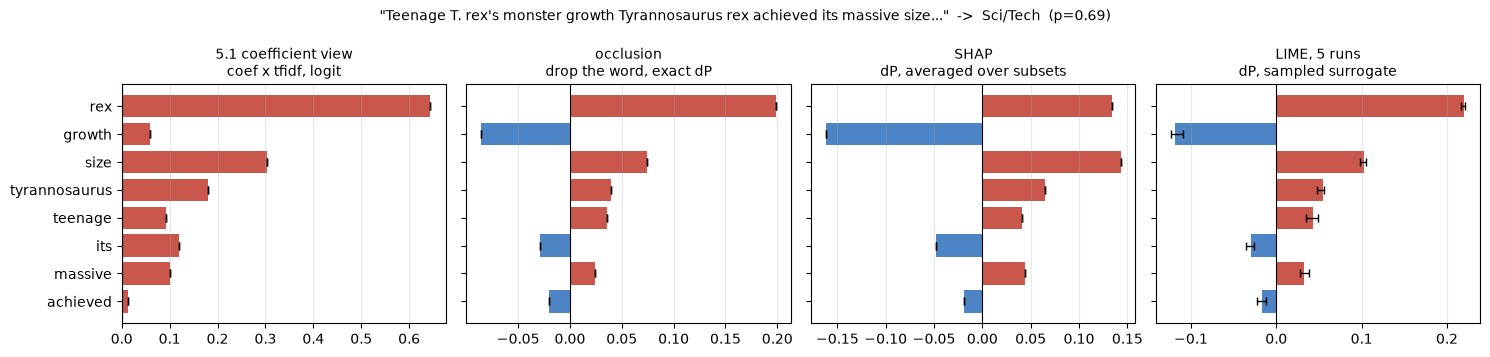

coefficients of 'growth' per class: {'World': np.float64(-1.15), 'Sports': np.float64(-1.72), 'Business': np.float64(2.67), 'Sci/Tech': np.float64(0.19)}


In [36]:
from collections import defaultdict
from lime.lime_text import LimeTextExplainer

lime_explainer = LimeTextExplainer(class_names=list(CLASS_NAMES.values()))
n_runs = 5
n_tok = len(re.findall(r"\w+", short))

t = time.time()
lime_runs = [dict((str(w).lower(), v) for w, v in
                  lime_explainer.explain_instance(
                      short, pipe.predict_proba, num_features=n_tok,
                      num_samples=500, labels=(cls,)).as_list(label=cls))
             for _ in range(n_runs)]
print(f"lime: {(time.time() - t) / n_runs:.2f}s per run, {n_runs} runs")

# 1. The coefficient view from 5.1: weight x feature value, in logit units.
x = vec_tfidf.transform([short])
coef_view = defaultdict(float)
for j, v in zip(x.indices, x.data):
    coef_view[feature_names[j]] += clf_tfidf.coef_[cls, j] * v

# 2. Occlusion: delete the word, ask again. Exact, one call per word.
p_full = pipe.predict_proba([short])[0, cls]
occlusion = {w: p_full - pipe.predict_proba(
                 [re.sub(rf"\b{re.escape(w)}\b", "", short, flags=re.I)])[0, cls]
             for w in coef_view}

# 3. SHAP, summed over repeated occurrences of the same word.
shap_view = defaultdict(float)
for w, v in zip(sv.data[0], sv.values[0][:, cls]):
    if str(w).strip():
        shap_view[str(w).strip().lower()] += float(v)

words = [w for w, _ in sorted(occlusion.items(), key=lambda kv: -abs(kv[1]))[:8]][::-1]
panels = [("5.1 coefficient view\ncoef x tfidf, logit", [[coef_view[w]] for w in words]),
          ("occlusion\ndrop the word, exact dP", [[occlusion[w]] for w in words]),
          ("SHAP\ndP, averaged over subsets", [[shap_view.get(w, 0.0)] for w in words]),
          (f"LIME, {n_runs} runs\ndP, sampled surrogate",
           [[r.get(w, 0.0) for r in lime_runs] for w in words])]

fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), sharey=True)
y = np.arange(len(words))
for ax, (title, vals) in zip(axes, panels):
    mean = np.array([np.mean(v) for v in vals])
    lo = np.array([min(v) for v in vals])
    hi = np.array([max(v) for v in vals])
    ax.barh(y, mean, alpha=.85,
            color=["#c0392b" if m > 0 else "#2c6fbb" for m in mean])
    ax.errorbar(mean, y, xerr=[mean - lo, hi - mean], fmt="none",
                ecolor="black", capsize=3, lw=1)
    ax.axvline(0, color="black", lw=.8)
    ax.set_title(title, fontsize=10)
    ax.grid(axis="x", alpha=.3)
axes[0].set_yticks(y)
axes[0].set_yticklabels(words)
fig.suptitle(f'"{short[:75]}..."  ->  {CLASS_NAMES[cls]}  (p={p_full:.2f})', fontsize=10)
plt.tight_layout(); plt.show()

print("coefficients of 'growth' per class:",
      dict(zip(CLASS_NAMES.values(),
               clf_tfidf.coef_[:, vec_tfidf.vocabulary_["growth"]].round(2))))

Read the disagreements.

**`growth` flips sign.** The coefficient view calls it a (weak) Sci/Tech word;
the three probability-based views say it pushes *away*. Both are right about
different questions — its weight for Business is +2.67 against +0.19 for
Sci/Tech, and a softmax probability is a competition between classes. Delete
`growth` and P(Sci/Tech) climbs by ~0.09, because Business fell further.

**`rex` and `size` swap places** between occlusion and SHAP: deleting one word
and averaging over subsets are different quantities once words interact.

**Only LIME has error bars** — it samples, so its output is a random variable.
Here five runs agree to within a few percent, which is not a general property:

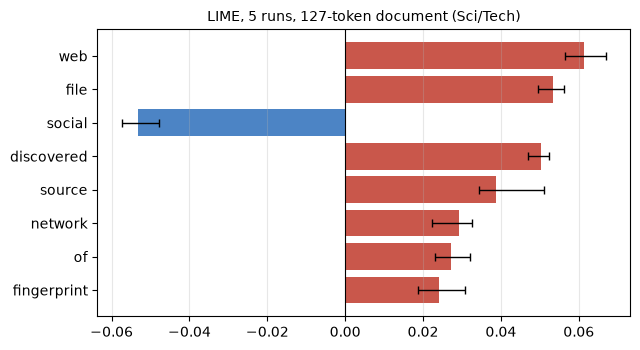

run 1: ['web', 'social', 'discovered', 'file', 'source']
run 2: ['web', 'file', 'discovered', 'social', 'source']
run 3: ['web', 'social', 'file', 'discovered', 'source']
run 4: ['web', 'social', 'file', 'source', 'discovered']
run 5: ['web', 'discovered', 'social', 'file', 'source']


In [37]:
# 🏠 Same method, same 500 samples, on a 127-token document instead of a headline.
long_doc = test.text.iloc[7]
cls_long = int(pipe.predict([long_doc])[0])
n_long = len(re.findall(r"\w+", long_doc))

runs_long = [dict((str(w).lower(), v) for w, v in
                  lime_explainer.explain_instance(
                      long_doc, pipe.predict_proba, num_features=n_long,
                      num_samples=500, labels=(cls_long,)).as_list(label=cls_long))
             for _ in range(n_runs)]

spread = {w: [r.get(w, 0.0) for r in runs_long] for w in set().union(*runs_long)}
top = [w for w, _ in sorted(spread.items(), key=lambda kv: -abs(np.mean(kv[1])))[:8]][::-1]

mean = np.array([np.mean(spread[w]) for w in top])
lo = np.array([min(spread[w]) for w in top])
hi = np.array([max(spread[w]) for w in top])
y = np.arange(len(top))

plt.figure(figsize=(6.5, 3.6))
plt.barh(y, mean, alpha=.85, color=["#c0392b" if m > 0 else "#2c6fbb" for m in mean])
plt.errorbar(mean, y, xerr=[mean - lo, hi - mean], fmt="none", ecolor="black",
             capsize=3, lw=1)
plt.yticks(y, top); plt.axvline(0, color="black", lw=.8); plt.grid(axis="x", alpha=.3)
plt.title(f"LIME, {n_runs} runs, {n_long}-token document "
          f"({CLASS_NAMES[cls_long]})", fontsize=10)
plt.tight_layout(); plt.show()

# The top-5 list you would paste into a slide, once per run.
for i, r in enumerate(runs_long, 1):
    print(f"run {i}: {[w for w, _ in sorted(r.items(), key=lambda kv: -abs(kv[1]))[:5]]}")

The bars overlap, and the top-5 lists are not the same list twice: below the
leader, `file`, `social` and `discovered` reshuffle on every run — on a model
that is completely deterministic. The surrogate is fit on 500 sampled
perturbations, and the space of perturbations grows with the number of tokens:
same budget, longer text, noisier estimate. (`lime`'s own default is
`num_samples=5000`.)

❓ **Open question 6:** if two runs disagree, what exactly is being explained?
And is reproducible the same as correct? SHAP above repeats to the last digit
and still disagrees with occlusion.

# 6. Static embeddings

Everything so far represents a word by its identity — a column index. Two
columns are equally far apart whether the words are `oil` and `petroleum` or
`oil` and `basketball`. Embeddings fix that by placing words in a space where
distance means something.

We will train word2vec on AG News. Friendly reminder about how word2vec is trained:

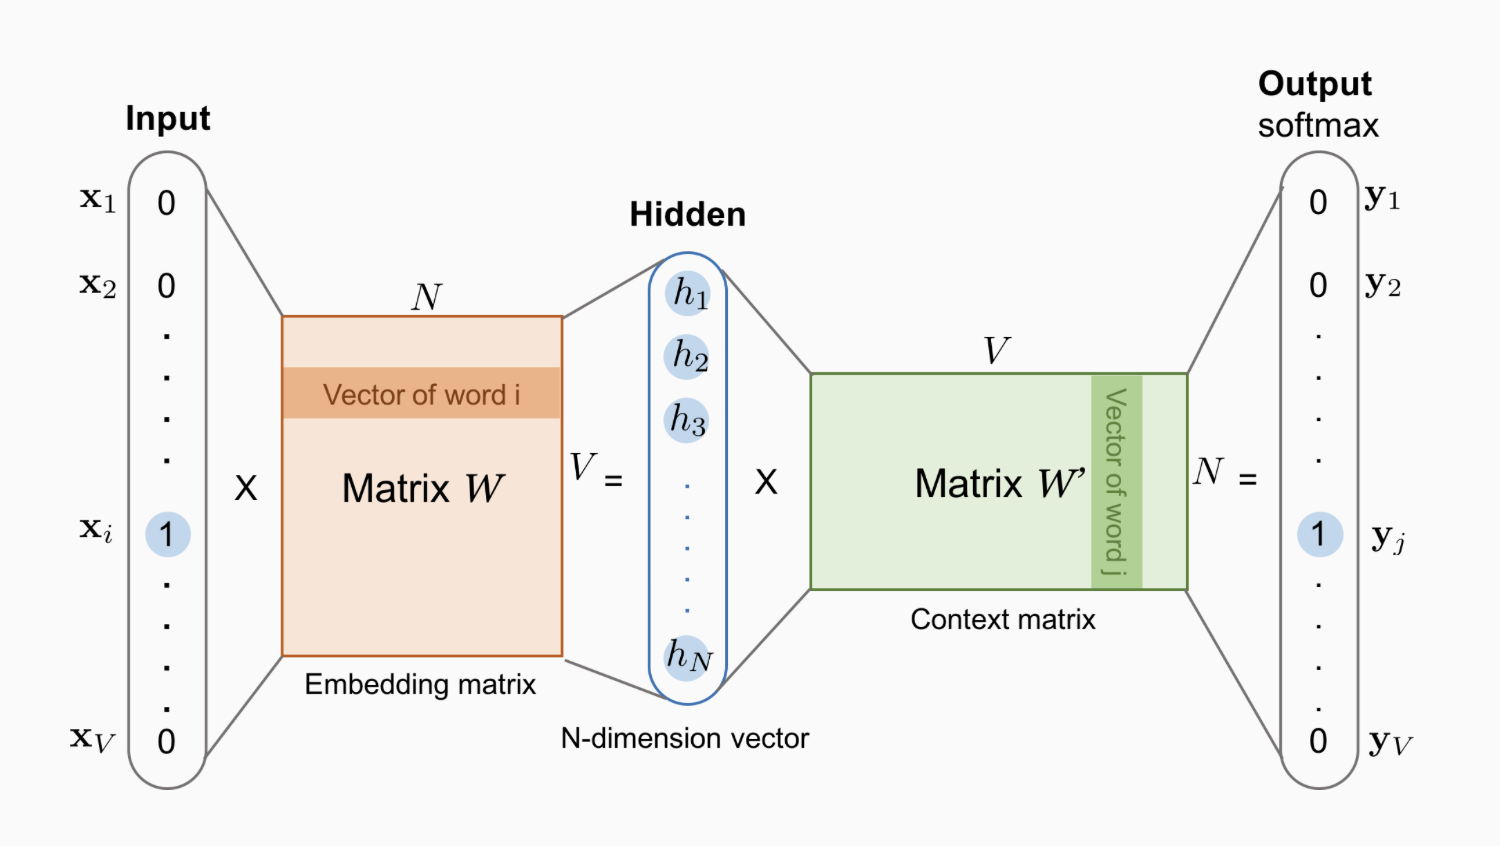

In [38]:
from gensim.models import Word2Vec

corpus = [re.findall(r"\w+", t.lower()) for t in train.text]

t = time.time()
w2v = Word2Vec(corpus, vector_size=100, window=5, min_count=5,
               sg=1, seed=SEED, workers=1, epochs=5).wv
print(f"trained in {time.time() - t:.0f}s, vocab {len(w2v):,}")

for w in ["oil", "microsoft", "olympic"]:
    print(f"\n{w}: {[x for x, _ in w2v.most_similar(w, topn=6)]}")

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

trained in 116s, vocab 27,811

oil: ['crude', 'petroleum', 'spr', 'prices', 'nymex', 'barrel']

microsoft: ['windows', 'novell', 'msft', 'microsofts', 'netware', 'longhorn']

olympic: ['athens', 'medal', 'olympics', 'gymnastics', 'medals', 'paralympic']


## 6.1 Does dropping stopwords hurt word2vec?

📌 **Bet:** we promised this test back in block 2.

In [39]:
corpus_nostop = [[w for w in doc if w not in stop] for doc in corpus]
w2v_nostop = Word2Vec(corpus_nostop, vector_size=100, window=5, min_count=5,
                      sg=1, seed=SEED, workers=1, epochs=5).wv

for w in ["oil", "election", "software"]:
    print(f"{w}")
    print(f"  with stopwords   : {[x for x, _ in w2v.most_similar(w, topn=5)]}")
    print(f"  without stopwords: {[x for x, _ in w2v_nostop.most_similar(w, topn=5)]}")

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


oil
  with stopwords   : ['crude', 'petroleum', 'spr', 'prices', 'nymex']
  without stopwords: ['crude', 'petroleum', 'prices', 'barrel', 'spr']
election
  with stopwords   : ['presidential', 'elections', 'ukrainians', 'polls', 'campaigning']
  without stopwords: ['presidential', 'elections', 'polls', 'electoral', 'vote']
software
  with stopwords   : ['apps', 'database', 'midmarket', 'jasc', 'wordperfect']
  without stopwords: ['apps', 'ciscos', 'jasc', 'application', 'wares']


Dropping stopwords changes which words land inside the same window. Words that
were six positions apart become adjacent. Whether that helps depends entirely on
what you want the neighbourhood to mean — which is, again, the block 2 rule.



## 6.2 fastText and out-of-vocabulary words

We're going to train it live, but if your Colab session is slow, drop `epochs` to 3. The OOV behaviour is
unchanged; only neighbour quality degrades slightly.

In [40]:
from gensim.models import FastText

t = time.time()
ft = FastText(corpus, vector_size=100, window=5, min_count=5,
              sg=1, seed=SEED, workers=1, epochs=5, min_n=3, max_n=5).wv
print(f"trained in {time.time() - t:.0f}s\n")

for w in ["biotechnologies", "unbelievability", "microsofts"]:
    in_w2v = w in w2v.key_to_index
    print(f"{w!r}  in word2vec vocab: {in_w2v}")
    if not in_w2v:
        print(f"  word2vec : KeyError")
    print(f"  fastText : {[x for x, _ in ft.most_similar(w, topn=5)]}\n")

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

trained in 248s

'biotechnologies'  in word2vec vocab: False
  word2vec : KeyError
  fastText : ['technologies', 'biotechnology', 'technologist', 'nanotechnology', 'technologists']

'unbelievability'  in word2vec vocab: False
  word2vec : KeyError
  fastText : ['inability', 'respectability', 'probability', 'unbelievable', 'disability']

'microsofts'  in word2vec vocab: True
  fastText : ['microsoft', 'windows', 'lindows', 'microwave', 'microbial']



Note that fastText's answers here are decent but not magic — on a clean news
corpus the subword advantage is modest, because there are few misspellings and
little morphology to exploit. On user-generated text or on Russian the gap is
much larger. Worth being honest that this demo undersells the method.

## 6.3 Pretrained embeddings, analogies, and a catch

We load a subset of `glove-twitter-100` — the top 60k words plus the ones this
seminar touches. The full model is 406 MB; the subset is 22 MB.

`gensim.downloader` is a catalogue of thirteen models frozen around 2020, which
is fine for GloVe — those vectors stopped changing in 2014. Anything published
since lives on the HuggingFace hub instead (the same GloVe vectors are mirrored
there as `fse/glove-twitter-100`). The library itself is not the stale part:
gensim 4.4.0 shipped in October 2025, while `torchtext` was archived in 2024.

In [41]:
import gensim.downloader as api

# Pretrained vectors are a download, not a training run. What is on offer:
catalog = api.info()["models"]
for name in ["glove-twitter-100", "word2vec-google-news-300", "word2vec-ruscorpora-300"]:
    print(f"{name:26s} {catalog[name]['file_size'] / 1e6:5.0f} MB")

# kv = api.load("glove-twitter-100")   # <- the real thing: 406 MB
# We ship the top-60k subset (22 MB) instead, so nobody watches a progress bar.

if RECOMPUTE:
    !python scripts/precompute.py --data-dir data --out artifacts --only glove

blob = np.load(f"{ART_DIR}/glove_twitter_100_subset.npz", allow_pickle=True)
glove_words = list(blob["words"])
glove_vecs = blob["vectors"]
glove_idx = {w: i for i, w in enumerate(glove_words)}
glove_norm = glove_vecs / np.linalg.norm(glove_vecs, axis=1, keepdims=True)

print(f"{len(glove_words):,} vectors, dim {glove_vecs.shape[1]}")


def nearest(vector, topn=5, exclude=()):
    sims = glove_norm @ (vector / np.linalg.norm(vector))
    order = np.argsort(-sims)
    out = []
    for i in order:
        w = glove_words[i]
        if w in exclude:
            continue
        out.append((w, round(float(sims[i]), 3)))
        if len(out) == topn:
            return out


def analogy(pos, neg, topn=5, exclude_inputs=True):
    v = sum(glove_vecs[glove_idx[w]] for w in pos) \
        - sum(glove_vecs[glove_idx[w]] for w in neg)
    return nearest(v, topn, exclude=set(pos + neg) if exclude_inputs else set())

glove-twitter-100            406 MB
word2vec-google-news-300    1744 MB
word2vec-ruscorpora-300      208 MB
60,004 vectors, dim 100


In [42]:
print("king - man + woman =", analogy(["woman", "king"], ["man"]))
print("paris - france + italy =", analogy(["italy", "paris"], ["france"]))
print("sock - foot + head =", analogy(["head", "sock"], ["foot"]))

king - man + woman = [('queen', 0.673), ('prince', 0.623), ('royal', 0.615), ('mother', 0.614), ('african', 0.57)]
paris - france + italy = [('roma', 0.652), ('italia', 0.648), ('verona', 0.625), ('venice', 0.617), ('hotel', 0.602)]
sock - foot + head = [('blow', 0.612), ('pants', 0.604), ('butt', 0.602), ('heads', 0.595), ('monkey', 0.584)]


The first two look like the famous result; the third one is nonsense. Alos, `most_similar` **excludes the input words from the output by construction.** Run the same arithmetic without that exclusion:

In [43]:
for pos, neg in [(["woman", "king"], ["man"]), (["italy", "paris"], ["france"])]:
    with_ex = analogy(pos, neg, topn=3, exclude_inputs=True)
    without = analogy(pos, neg, topn=3, exclude_inputs=False)
    print(f"{pos} - {neg}")
    print(f"  inputs excluded : {with_ex}")
    print(f"  inputs kept     : {without}\n")

['woman', 'king'] - ['man']
  inputs excluded : [('queen', 0.673), ('prince', 0.623), ('royal', 0.615)]
  inputs kept     : [('king', 0.69), ('queen', 0.673), ('woman', 0.634)]

['italy', 'paris'] - ['france']
  inputs excluded : [('roma', 0.652), ('italia', 0.648), ('verona', 0.625)]
  inputs kept     : [('italy', 0.805), ('roma', 0.652), ('paris', 0.649)]



With the inputs kept, the nearest vector to `king − man + woman` is **`king`
itself**. `queen` is second, and close.

The arithmetic is not moving you to a new region of the space. It is barely
moving you at all — and the impressive demo is largely a little trick to demonstrate the concepts we tried to reach (remember? we wanted to include the semantic features to the embeddings construction).

See Nissim, van Noord & van der Goot (2020), *Fair is Better than Sensational*.



## 6.4 Bias

The same arithmetic, pointed somewhere uncomfortable.

In [ ]:
for pos, neg in [(["woman", "doctor"], ["man"]),
                 (["man", "nurse"], ["woman"]),
                 (["woman", "programmer"], ["man"])]:
    print(f"{pos} - {neg}")
    print(f"  {[w for w, _ in analogy(pos, neg, topn=6)]}\n")

Now, remember, these vectors were trained on Twitter around 2014. They encode what that corpus
said about who does which job, and any system built on top inherits it silently, so model will accept every type of -ism you'll show it. The same concept will follow us during the whole course — it is the same mechanism in every model this course will touch, even the biggest ones and the modern ones. See Bolukbasi
et al. (2016).


## 6.5 From words to documents

To classify with the word-embeddings we need one vector per document. There are several ways to achieve it, but I'll simplify everything to pooling by now. The most obvious one is mean-pooling: just average out all the word-embeddings of the doc to get the document's embeddings.

In [44]:
def embed_mean(texts, kv, idf=None, vocab=None):
    dim = kv.vector_size
    out = np.zeros((len(texts), dim), dtype=np.float32)
    for i, text in enumerate(texts):
        toks = [t for t in re.findall(r"\w+", text.lower()) if t in kv.key_to_index]
        if not toks:
            continue
        vecs = np.stack([kv[t] for t in toks])
        if idf is None:
            out[i] = vecs.mean(axis=0)
        else:
            w = np.array([idf.get(t, 1.0) for t in toks])[:, None]
            out[i] = (vecs * w).sum(axis=0) / w.sum()
    return out

idf_map = dict(zip(vec_tfidf.get_feature_names_out(), vec_tfidf.idf_))

for tag, kw in [("mean pooling", {}), ("idf-weighted", {"idf": idf_map})]:
    t = time.time()
    Etr = embed_mean(train.text, w2v, **kw)
    Ete = embed_mean(test.text, w2v, **kw)
    vec_s = time.time() - t

    t = time.time()
    clf = LogisticRegression(max_iter=2000, random_state=SEED).fit(Etr, train.label)
    fit_s = time.time() - t

    record(f"word2vec, {tag}", "LogisticRegression", test.label,
           clf.predict(Ete), vec_s, fit_s, note="dim=100")

    if tag == "mean pooling":          # kept for the learning curve at the end
        Etr_mean, Ete_mean = Etr, Ete

show_results()

,representation,head,accuracy,macro_f1,vectorize_s,fit_s,latency_ms,note
0,"counts, words 1-1",LogisticRegression,0.9093,0.9092,2.1,12.5,None,"dim=29,350"
1,"tf-idf, words 1-1",LogisticRegression,0.9179,0.9177,2.3,3.8,None,"dim=29,350"
2,"tf-idf, words 1-2",LogisticRegression,0.9195,0.9193,7.0,15.5,None,"dim=196,911"
3,"tf-idf, chars 3-5",LogisticRegression,0.9162,0.9160,24.2,66.0,None,"dim=177,100"
4,"tf-idf, words 1-1",LinearSVC,0.9195,0.9193,NaN,11.0,None,head swap
5,"tf-idf, words 1-1",MultinomialNB,0.9014,0.9012,NaN,0.1,None,head swap
6,"tf-idf, words 1-1",SGDClassifier,0.9192,0.9190,NaN,1.5,None,head swap
7,"word2vec, mean pooling",LogisticRegression,0.8899,0.8897,8.1,2.1,None,dim=100
8,"word2vec, idf-weighted",LogisticRegression,0.8900,0.8898,8.6,2.6,None,dim=100


**Averaged embeddings lose to TF-IDF.** A representation from 2013 with real
semantics inside it loses to one from 1972 that knows nothing but counts. TF-IDF hands
the classifier one parameter per word. Mean pooling hands it 100 numbers produced *before the labels
were seen*: every word's contribution is fixed by the embedding, and a single
decisive rare word is diluted to 1/n of the average. The head cannot undo that
compression, however good the compression is.

The lesson is not "embeddings are bad". It is **run the strong simple baseline
first**, because you will not otherwise know whether the sophisticated thing
earned its cost — and know which side of that crossing point you are on.

❓ **Open question 7:** what would a better aggregation than the mean look like?
(Look up SIF weighting, Arora et al. 2017 — it is three lines of code and it
does help.)

# 7. An LLM does this too

It is not a secret, that you can perform the simpliest classification by just asking any LLM "what the class is this out of four?" (using a so-called zero-shot or few-shot prompting). The method exists, it is used in industry, and it needs no labelled data at all, which is another huge advantage, on what the previous models and methods weren't capable of. But there is another thing we need to discuss.

Predictions for 200 test examples — two prompts, three repeats each, `temperature=0` — are precomputed so we can look at the failure modes rather than watch a progress bar.

In [45]:
llm_path = f"{ART_DIR}/llm_predictions.csv"

if os.path.exists(llm_path):
    llm = pd.read_csv(llm_path)
    print(f"{len(llm):,} API calls  |  {llm.idx.nunique()} unique examples")
    print(f"prompts: {sorted(llm.prompt.unique())}  repeats: {llm.repeat.nunique()}")
    llm.head(3)
else:
    print("No LLM artifact — instructor demo only. See scripts/precompute.py --only llm")

1,200 API calls  |  200 unique examples
prompts: ['A', 'B']  repeats: 3


In [46]:
if os.path.exists(llm_path):
    name2id = {v.lower().replace("/", "").replace("-", ""): k
               for k, v in CLASS_NAMES.items()}

    def parse(raw):
        key = str(raw).strip().lower().replace("/", "").replace("-", "").replace(" ", "")
        return name2id.get(key, -1)

    llm["pred"] = llm["raw"].map(parse)

    # 1. Accuracy, and how much it moves with a cosmetic prompt change.
    print("accuracy by prompt and repeat")
    print(llm.groupby(["prompt", "repeat"])
             .apply(lambda g: (g.pred == g.gold).mean())
             .round(3).to_string())

accuracy by prompt and repeat
prompt  repeat
A       0         0.820
        1         0.830
        2         0.825
B       0         0.880
        1         0.880
        2         0.880


In [47]:
if os.path.exists(llm_path):
    # 2. Non-determinism at temperature=0.
    per_example = (llm[llm.prompt == "A"]
                   .groupby("idx")["pred"].nunique())
    unstable = (per_example > 1).mean()
    print(f"examples where 3 identical calls disagreed: {unstable:.1%}")

    # 3. Latency, straight into the results table.
    print(f"\nmedian latency: {llm.latency_s.median() * 1000:.0f} ms per example")
    print(f"vs TF-IDF, which vectorizes 7,600 documents in ~3 s total")

    best = llm[(llm.prompt == "A") & (llm.repeat == 0)]
    record("zero-shot LLM", "LLM", best.gold, best.pred,
           latency_ms=int(best.latency_s.median() * 1000),
           note="200 examples, no training data")
    show_results()

examples where 3 identical calls disagreed: 1.5%

median latency: 587 ms per example
vs TF-IDF, which vectorizes 7,600 documents in ~3 s total


Look at the columns side by side.

**What it costs:**
* Latency per example is three to four orders of magnitude above TF-IDF. On the
  full test set that is the difference between three seconds and an hour.
* Identical calls at `temperature=0` can disagree. The same input does not
  reliably produce the same output.
* Reordering the class list in the prompt — a change with no semantic content —
  moves accuracy.
* No calibrated probability. `predict_proba` from the logistic regression is a
  real number you can threshold (if you don't get the reference, check out the topic of calibration curves from ML); a generated string is not.
* Opaque. Two blocks ago we read the model's reasoning off a coefficient vector.

**What it buys:** it needed zero labelled examples. On a task where nobody has
annotated 120 000 documents, that is not a minor convenience — it is the
difference between having a system and not having one.

❓ **Open question 8:** why does `temperature=0` not guarantee identical
outputs? (Hint: it has nothing to do with sampling. Look up batching and
floating-point non-associativity.)

🏠 **Homework:** the graph that actually answers "should I use an LLM here" is
accuracy against the number of labelled examples. TF-IDF starts at chance and
climbs; zero-shot is a flat line. Where they cross is your answer.

In [ ]:
# 🏠 Learning curve. TF-IDF side runs in about a minute.
sizes = [50, 100, 250, 500, 1000, 2500, 5000, 10000, 30000, 120000]
curve = []
rng = np.random.RandomState(SEED)

for n in sizes:
    # YOUR CODE HERE: sample n rows from train,
    # fit TF-IDF and word2vec mean, record test accuracy

curve = pd.DataFrame(curve, columns=["n_labelled", "tfidf", "word2vec_mean"])

plt.figure(figsize=(7, 4))
plt.semilogx(curve.n_labelled, curve.tfidf, "o-", label="TF-IDF + LogReg")
plt.semilogx(curve.n_labelled, curve.word2vec_mean, "o-", label="word2vec mean + LogReg")
if os.path.exists(llm_path):
    llm_acc = (llm[(llm.prompt == "A") & (llm.repeat == 0)].pipe(
        lambda g: (g.pred == g.gold).mean()))
    plt.axhline(llm_acc, ls="--", color="crimson", label="zero-shot LLM")
plt.xlabel("labelled training examples"); plt.ylabel("test accuracy")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
curve

# 8. The ceiling

To the fun facts, but using the NLP-like examples:

Look at the spread in the results table. Every approach we tried — a 1972
representation, a 2013 one, a 2026 one — lands within a few points of the
others.

That is suspicious. Either all these methods are equally good, or something
other than the method is setting the limit.

Time to use the number you produced while labelling!

In [48]:
df = show_results()
print(f"best : {df.accuracy.max():.4f}")
print(f"worst: {df.accuracy.min():.4f}")
print(f"spread: {df.accuracy.max() - df.accuracy.min():.4f}")
df.sort_values("accuracy", ascending=False)

best : 0.9195
worst: 0.8200
spread: 0.0995


,representation,head,accuracy,macro_f1,vectorize_s,fit_s,latency_ms,note
2,"tf-idf, words 1-2",LogisticRegression,0.9195,0.9193,7.0,15.5,NaN,"dim=196,911"
4,"tf-idf, words 1-1",LinearSVC,0.9195,0.9193,NaN,11.0,NaN,head swap
6,"tf-idf, words 1-1",SGDClassifier,0.9192,0.9190,NaN,1.5,NaN,head swap
1,"tf-idf, words 1-1",LogisticRegression,0.9179,0.9177,2.3,3.8,NaN,"dim=29,350"
3,"tf-idf, chars 3-5",LogisticRegression,0.9162,0.9160,24.2,66.0,NaN,"dim=177,100"
0,"counts, words 1-1",LogisticRegression,0.9093,0.9092,2.1,12.5,NaN,"dim=29,350"
5,"tf-idf, words 1-1",MultinomialNB,0.9014,0.9012,NaN,0.1,NaN,head swap
8,"word2vec, idf-weighted",LogisticRegression,0.8900,0.8898,8.6,2.6,NaN,dim=100
7,"word2vec, mean pooling",LogisticRegression,0.8899,0.8897,8.1,2.1,NaN,dim=100
9,zero-shot LLM,LLM,0.8200,0.8206,NaN,NaN,609.0,"200 examples, no training data"


In [49]:
# Twenty mistakes from the best model, read by hand.
pred_best = clf_tfidf.predict(Xte_tfidf)
wrong = np.where(pred_best != test.label.values)[0]
sample = np.random.RandomState(SEED).choice(wrong, size=20, replace=False)

for i in sample[:20]:
    print(f"gold={CLASS_NAMES[test.label.iloc[i]]:9s} "
          f"pred={CLASS_NAMES[pred_best[i]]:9s} | {test.text.iloc[i][:110]}")

gold=Sci/Tech  pred=Business  | Microsoft braces for crucial TV test Comcast trials will provide a big clue about the software giant's prospec
gold=World     pred=Business  | Argentina gets China investment China is to invest nearly \$20bn (11bn) in Argentina over the next 10 years, A
gold=Business  pred=World     | Heathrow refuellers to push ahead with strike plans Aircraft refuellers at Heathrow Airport have vowed to push
gold=Sports    pred=Sci/Tech  | World awaits Chinese Grand Prix A quarter of a billion dollars to build the track. Tens of millions in racing 
gold=Sci/Tech  pred=World     | Court ruling has fat cats purring THE future of horseracing in Britain was thrown into confusion this week as 
gold=World     pred=Business  | ConocoPhillips boosts LUKoil stake to 10 percent (AFP) AFP - US oil major ConocoPhillips has boosted its stake
gold=Sports    pred=World     | TV war puts tour of India in doubt Australian cricket chiefs fear a battle over television rights could cause 

In [50]:
# The twelve from block 0b, with what the dataset says.
gold12 = test.label.iloc[DISPUTED_IDX].values
pred12 = clf_tfidf.predict(vec_tfidf.transform(test.text.iloc[DISPUTED_IDX]))

for n, i in enumerate(DISPUTED_IDX, 1):
    print(f"{n:2d}. dataset={CLASS_NAMES[gold12[n-1]]:9s} model={CLASS_NAMES[pred12[n-1]]:9s}"
          f" | {test.text.iloc[i][:80]}")
print(f"\nmodel agrees with the dataset on {(pred12 == gold12).mean():.0%} of these twelve")
print(f"(it gets {accuracy_score(test.label, pred_best):.0%} on the test set as a whole)")

 1. dataset=World     model=Business  | Week's delay for Delta launcher Boeing's new heavy-lift Delta 4 rocket must wait
 2. dataset=Sports    model=Sci/Tech  | Honda aiming for BAR buyout? Motorsport.com. Reports this week suggest that Hond
 3. dataset=Sci/Tech  model=Business  | PeopleSoft Chief Threatens to Sue Over Oracle Statements PeopleSoft's chief exec
 4. dataset=World     model=Sports    | Sri Lanka off to positive start Kumar Sangakkara's unbeaten fifty revives Sri La
 5. dataset=Sci/Tech  model=World     | JFK killing fades in intensity WASHINGTON: The 41st anniversary of President Joh
 6. dataset=Sci/Tech  model=Sci/Tech  | Court: Whales Have No Standing to Sue (AP) AP - A federal appeals court decided 
 7. dataset=Business  model=Sci/Tech  | BAE included in SFO investigation BAE Systems says it has found out that it is b
 8. dataset=Sci/Tech  model=Sports    | Travel Column: Australia Through Aboriginal Eyes This week's TravelWatch column 
 9. dataset=Sci/Tech  model=Worl

Look at what the dataset claims about some of these. A cricket match filed under
World. The anniversary of the Kennedy assassination filed under Sci/Tech. A
travel column about Aboriginal-owned tours, also Sci/Tech.

Those are not hard examples. They are **wrong labels**, and there is no method of
representation that fixes them.

**Now put the numbers together.** Your agreement rate from the labelling, the class's
agreement with each other, and the spread between every model we built today are
all in the same neighbourhood.

That means the accuracy still missing is not sitting in a better representation.
It is sitting in the label definition. If you want the next percentage point,
you go back to the annotation guidelines, not to the hyperparameters.

# 9. Putting it together

In [51]:
final = show_results().sort_values("accuracy", ascending=False)
final

,representation,head,accuracy,macro_f1,vectorize_s,fit_s,latency_ms,note
2,"tf-idf, words 1-2",LogisticRegression,0.9195,0.9193,7.0,15.5,NaN,"dim=196,911"
4,"tf-idf, words 1-1",LinearSVC,0.9195,0.9193,NaN,11.0,NaN,head swap
6,"tf-idf, words 1-1",SGDClassifier,0.9192,0.9190,NaN,1.5,NaN,head swap
1,"tf-idf, words 1-1",LogisticRegression,0.9179,0.9177,2.3,3.8,NaN,"dim=29,350"
3,"tf-idf, chars 3-5",LogisticRegression,0.9162,0.9160,24.2,66.0,NaN,"dim=177,100"
0,"counts, words 1-1",LogisticRegression,0.9093,0.9092,2.1,12.5,NaN,"dim=29,350"
5,"tf-idf, words 1-1",MultinomialNB,0.9014,0.9012,NaN,0.1,NaN,head swap
8,"word2vec, idf-weighted",LogisticRegression,0.8900,0.8898,8.6,2.6,NaN,dim=100
7,"word2vec, mean pooling",LogisticRegression,0.8899,0.8897,8.1,2.1,NaN,dim=100
9,zero-shot LLM,LLM,0.8200,0.8206,NaN,NaN,609.0,"200 examples, no training data"


Back to block 0. Every row bought something and paid for something, and there
is still no winner. Pick by what your problem is short of — labelled data,
latency budget, interpretability, or predictability.

**Four things that transfer to any text task:**

1. **Strong sparse baseline first, always.** It is an hour of work and it is
   frequently the answer.
2. **Complexity has to pay for itself** in whichever column your problem
   actually cares about.
3. **Explanations are a debugging tool for your data**, not a deliverable.
4. **The ceiling is set by the data.** When every method lands in the same
   narrow band, stop tuning and go read the labels.

## Homework in this notebook (voluntary)

Everything marked 🏠 above runs as-is. Plus:

* SIF weighting against mean pooling (6.5).
* Ordinal regression on a rating dataset (4).
* Train your own tokenizer on AG News and compare token counts (1.2).

## References (check this out to know more)

* Nissim, van Noord, van der Goot (2020). [*Fair is Better than Sensational:
  Man is to Doctor as Woman is to Doctor.*](https://arxiv.org/abs/1905.09866)
  Computational Linguistics 46(2)
* Bolukbasi et al. (2016). [*Man is to Computer Programmer as Woman is to
  Homemaker? Debiasing Word Embeddings.*](https://arxiv.org/abs/1607.06520)
  NeurIPS 2016
* Arora, Liang, Ma (2017). [*A Simple but Tough-to-Beat Baseline for Sentence
  Embeddings.*](https://openreview.net/forum?id=SyK00v5xx) ICLR 2017 — not on arXiv; the OpenReview page has the PDF.
* Bojanowski et al. (2017). [*Enriching Word Vectors with Subword
  Information.*](https://arxiv.org/abs/1607.04606) TACL 5.
* Wattenberg, Viégas, Johnson (2016). [*How to Use t-SNE
  Effectively.*](https://distill.pub/2016/misread-tsne/) distill.pub.
* Jay Alammar. [*The Illustrated
  Word2vec.*](https://jalammar.github.io/illustrated-word2vec/) — background
  for block 6.